# 🎬 Semantic Video Search with MATA Graph

**New in v1.9.7** — two graph nodes (`IndexVideo` + `EmbeddingSearch`) turn any video into a searchable embedding index you can query with plain text.

```
VideoPath → IndexVideo → VideoIndexData → EmbeddingSearch → SearchResults
```

This notebook covers:

- **Quick demo** — Qwen3-VL-Embedding on a dashcam clip
- **Inspecting results** — `SearchResults`, `QueryResult`, `VideoMatch` API
- **Multi-query graph** — batch all queries in a single node call
- **Matryoshka truncation** — compact 256-D embeddings

**Prerequisites**: `pip install datamata[notebook]`

> **Hardware note**  
> `Qwen/Qwen3-VL-Embedding-2B` requires a CUDA GPU with ≥ 8 GB VRAM and `dtype="bfloat16"`.  
> For CPU-only machines use `dtype="float32"` (slower, ~16 GB RAM recommended).

- Demo video  : examples/videos/dashcam_bus.mp4
                "Streets of London at Night"
                (by George Morina — https://www.pexels.com/video/streets-of-london-at-night-5823504/)

In [ ]:
# Uncomment to install:
# !pip install datamata[notebook]

In [2]:
import sys
sys.path.insert(0, "../../src")

from pathlib import Path
import mata
from mata.core.graph.graph import Graph
from mata.nodes import IndexVideo, EmbeddingSearch

print(f"MATA version: {mata.__version__}")

VIDEO = str(Path("../../examples/videos/dashcam_bus.mp4").resolve())
status = "✅ FOUND" if Path(VIDEO).exists() else "❌ NOT FOUND — check examples/videos/"
print(f"Video file  : {status}")

MATA version: 1.9.7
Video file  : ✅ FOUND


## 1️⃣ Load the Embedding Model

`Qwen/Qwen3-VL-Embedding-2B` uses a full VLM backbone — ideal for rich scene
descriptions and safety-critical queries that contrastive models often miss.

Load it with `dtype="bfloat16"` for GPU inference (recommended), or `dtype="float32"` for CPU.

In [3]:
import torch

DTYPE = "bfloat16"
print(f"Device : {'CUDA' if torch.cuda.is_available() else 'CPU'}  |  dtype : {DTYPE}")

embedder = mata.load("embed", "Qwen/Qwen3-VL-Embedding-2B", dtype=DTYPE)
print(f"Model loaded  : Qwen/Qwen3-VL-Embedding-2B")

Device : CUDA  |  dtype : bfloat16
[INFO] Loading embed model from huggingface: Qwen/Qwen3-VL-Embedding-2B
[INFO] Loading Qwen3-VL-Embedding: Qwen/Qwen3-VL-Embedding-2B on cuda (torch.bfloat16)


Loading weights: 100%|██████████| 625/625 [00:00<00:00, 6368.79it/s]


Model loaded  : Qwen/Qwen3-VL-Embedding-2B


## 2️⃣ Build & Run the Search Graph

The full pipeline is **three lines of graph API**:

```python
Graph("urban_traffic_search")
  .then(IndexVideo(using="embedder", sample_fps=1.0))
  .then(EmbeddingSearch(using="embedder", text=[...], top_k=3))
```

`IndexVideo` samples one frame per second, embeds each frame, and stores
everything in a `VideoIndexData` artifact.  `EmbeddingSearch` embeds your
text queries and performs nearest-neighbour search against that index.

In [3]:
queries = [
    "red double-decker bus",
    "traffic lights at night",
    "pedestrian crossing the road",
]

result = (
    Graph("urban_traffic_search")
    .then(IndexVideo(using="embedder", sample_fps=1.0))
    .then(EmbeddingSearch(using="embedder", text=queries, top_k=3, threshold=0.20))
).run(video=VIDEO, providers={"embedder": embedder})

sr = result["search_results"]
print(f"Graph finished.")
print(f"Artifact type : {type(sr).__name__}")
print(f"Queries run   : {len(sr)}")

[INFO] Starting synchronous execution of graph 'urban_traffic_search'
[INFO] Graph 'urban_traffic_search' completed in 95174.83ms (2 nodes)
Graph finished.
Artifact type : SearchResults
Queries run   : 3


## 3️⃣ Inspect the Results

`result["search_results"]` is a `SearchResults` artifact.  
Iterate it to get one `QueryResult` per query — each carries a tuple of `VideoMatch` objects.

In [4]:
for qr in sr:
    print(f'\nQuery: "{qr.query}"')
    if not qr.matches:
        print("  (no matches above threshold)")
        continue
    for rank, m in enumerate(qr.matches, 1):
        mm, ss = int(m.start_s) // 60, int(m.start_s) % 60
        print(f"  #{rank}  sim={m.similarity:.4f}  @ {mm:02d}m{ss:02d}s  [{m.label}]")


Query: "red double-decker bus"
  #1  sim=0.5820  @ 00m12s  [frame_000377]
  #2  sim=0.5582  @ 00m13s  [frame_000406]
  #3  sim=0.5444  @ 01m11s  [frame_002146]

Query: "traffic lights at night"
  #1  sim=0.6296  @ 00m54s  [frame_001624]
  #2  sim=0.6257  @ 00m53s  [frame_001595]
  #3  sim=0.6241  @ 00m52s  [frame_001566]

Query: "pedestrian crossing the road"
  #1  sim=0.5975  @ 01m26s  [frame_002581]
  #2  sim=0.5871  @ 01m48s  [frame_003248]
  #3  sim=0.5771  @ 01m50s  [frame_003306]


In [5]:
# SearchResults supports len(), index access, and rich notebook display
print(f"len(sr)          = {len(sr)}")
print(f"sr[0].query      = {sr[0].query!r}")
print(f"sr[0].matches[0] = label={sr[0].matches[0].label!r}, "
      f"similarity={sr[0].matches[0].similarity:.4f}, "
      f"start_s={sr[0].matches[0].start_s:.1f}s")

len(sr)          = 3
sr[0].query      = 'red double-decker bus'
sr[0].matches[0] = label='frame_000377', similarity=0.5820, start_s=12.6s


In [6]:
# Evaluate the artifact directly for an HTML summary table in JupyterLab
sr

SearchResults(results=(QueryResult(query='red double-decker bus', matches=(VideoMatch(label='frame_000377', similarity=0.5820168256759644, index=13, start_s=12.579233333333333, end_s=12.579233333333333), VideoMatch(label='frame_000406', similarity=0.55824875831604, index=14, start_s=13.546866666666666, end_s=13.546866666666666), VideoMatch(label='frame_002146', similarity=0.5444427132606506, index=74, start_s=71.60486666666667, end_s=71.60486666666667))), QueryResult(query='traffic lights at night', matches=(VideoMatch(label='frame_001624', similarity=0.6295857429504395, index=56, start_s=54.187466666666666, end_s=54.187466666666666), VideoMatch(label='frame_001595', similarity=0.6257128119468689, index=55, start_s=53.219833333333334, end_s=53.219833333333334), VideoMatch(label='frame_001566', similarity=0.6240649223327637, index=54, start_s=52.2522, end_s=52.2522))), QueryResult(query='pedestrian crossing the road', matches=(VideoMatch(label='frame_002581', similarity=0.59746313095092

## 4️⃣ Visualise Match Scores

Plot similarity scores per query to visualise how the model ranks
each concept in this video.

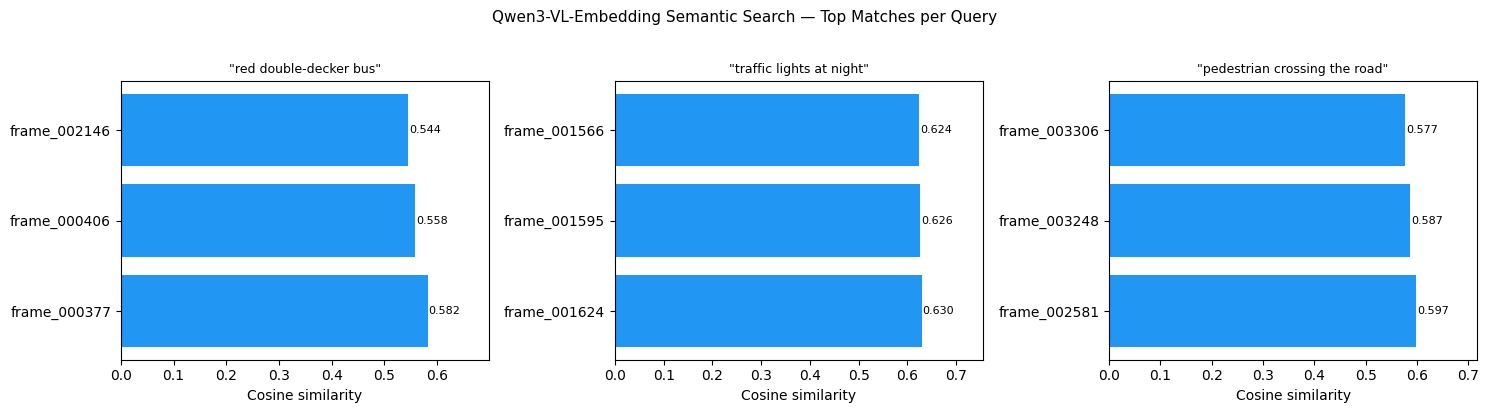

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, len(sr), figsize=(5 * len(sr), 4), sharey=False)
if len(sr) == 1:
    axes = [axes]

for ax, qr in zip(axes, sr):
    if not qr.matches:
        ax.set_title(qr.query[:40], fontsize=9)
        ax.text(0.5, 0.5, "no matches", ha="center", va="center", transform=ax.transAxes)
        continue
    labels = [m.label for m in qr.matches]
    scores = [m.similarity for m in qr.matches]
    colors = ["#2196F3" if s >= 0.20 else "#90CAF9" for s in scores]
    bars = ax.barh(labels, scores, color=colors)
    ax.set_xlim(0, max(scores) * 1.2)
    ax.set_title(f'"{qr.query[:40]}"', fontsize=9, wrap=True)
    ax.set_xlabel("Cosine similarity")
    for bar, score in zip(bars, scores):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{score:.3f}", va="center", fontsize=8)

plt.suptitle("Qwen3-VL-Embedding Semantic Search — Top Matches per Query", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 5️⃣ Multi-Query Graph — All Tiers in One Call

Passing a list to `EmbeddingSearch` embeds and searches **all queries in a single
node execution** — one index build, many queries.  Queries are organised in three
tiers of increasing complexity.

In [8]:
QUERIES_ALL = [
    # Tier 1 — simple concepts
    "red double-decker bus",
    "traffic lights at night",
    "a parked taxi",
    # Tier 2 — descriptive
    "vehicles merging at a busy junction",
    "wet road surface reflecting street lights",
    "pedestrian waiting to cross the road",
    # Tier 3 — complex / safety-critical
    "person dangerously jaywalking between moving vehicles",
    "cyclist weaving through fast-moving traffic at night",
]

result_all = (
    Graph("traffic_search_all_tiers")
    .then(IndexVideo(using="embedder", sample_fps=1.0))
    .then(EmbeddingSearch(using="embedder", text=QUERIES_ALL, top_k=3, threshold=0.18))
).run(video=VIDEO, providers={"embedder": embedder})

sr_all = result_all["search_results"]
tier_labels = ["T1"] * 3 + ["T2"] * 3 + ["T3"] * 2

print(f"{'Tier':<4}  {'Query':<55}  {'Top match'}")
print("-" * 85)
for tier, qr in zip(tier_labels, sr_all):
    top = qr.matches[0] if qr.matches else None
    ts  = (f"sim={top.similarity:.3f}  @ "
            f"{int(top.start_s)//60:02d}m{int(top.start_s)%60:02d}s  [{top.label}]"
            if top else "no match above threshold")
    print(f"[{tier}]  {qr.query[:55]:<55}  {ts}")

[INFO] Starting synchronous execution of graph 'traffic_search_all_tiers'
[INFO] Graph 'traffic_search_all_tiers' completed in 88660.46ms (2 nodes)
Tier  Query                                                    Top match
-------------------------------------------------------------------------------------
[T1]  red double-decker bus                                    sim=0.582  @ 00m12s  [frame_000377]
[T1]  traffic lights at night                                  sim=0.630  @ 00m54s  [frame_001624]
[T1]  a parked taxi                                            sim=0.464  @ 00m53s  [frame_001595]
[T2]  vehicles merging at a busy junction                      sim=0.601  @ 00m04s  [frame_000145]
[T2]  wet road surface reflecting street lights                sim=0.592  @ 00m23s  [frame_000696]
[T2]  pedestrian waiting to cross the road                     sim=0.568  @ 01m26s  [frame_002581]
[T3]  person dangerously jaywalking between moving vehicles    sim=0.629  @ 01m26s  [frame_002581]


## 6️⃣ Matryoshka Dimension Truncation

Qwen3-VL-Embedding supports **Matryoshka Representation Learning** — truncate
embeddings to a smaller dimension for faster search with a small accuracy trade-off.

Supported dims: `64, 128, 256, 512, 1024, 2048, 4096` (native).

In [ ]:
import torch

if not torch.cuda.is_available():
    print("⚠️  Skipping — GPU required for Qwen3.")
else:
    # Better Restart the previous cell to free GPU memory before running this one, as it will load another instance of the model.
    embedder_256 = mata.load(
        "embed",
        "Qwen/Qwen3-VL-Embedding-2B",
        dtype="bfloat16",
        embed_dim=256,          # Matryoshka truncation
    )

    result_256 = (
        Graph("qwen3_matryoshka_search")
        .then(IndexVideo(using="embedder", sample_fps=1.0, embed_dim=256))
        .then(EmbeddingSearch(
            using="embedder",
            text=["red bus", "jaywalking pedestrian"],
            top_k=3,
            threshold=0.18,
        ))
    ).run(video=VIDEO, providers={"embedder": embedder_256})

    print("embed_dim=256 results\n" + "-" * 40)
    for qr in result_256["search_results"]:
        top = qr.matches[0] if qr.matches else None
        ts  = (f"sim={top.similarity:.4f}  @ "
                f"{int(top.start_s)//60:02d}m{int(top.start_s)%60:02d}s"
                if top else "no match")
        print(f'  "{qr.query}" → {ts}')

[INFO] Loading embed model from huggingface: Qwen/Qwen3-VL-Embedding-2B
[INFO] Loading Qwen3-VL-Embedding: Qwen/Qwen3-VL-Embedding-2B on cuda (torch.bfloat16)


Loading weights: 100%|██████████| 625/625 [00:00<00:00, 6021.68it/s]


[INFO] Starting synchronous execution of graph 'qwen3_matryoshka_search'
[INFO] Graph 'qwen3_matryoshka_search' completed in 87586.11ms (2 nodes)
embed_dim=256 results
----------------------------------------
  "red bus" → sim=0.6103  @ 00m12s
  "jaywalking pedestrian" → sim=0.6325  @ 01m48s


## 7️⃣ Use Your Own Video

Swap the path and queries to search any video file:

```python
MY_VIDEO = "/path/to/my_footage.mp4"
MY_QUERIES = ["my concept A", "my concept B"]

result = (
    Graph("my_search")
    .then(IndexVideo(using="embedder", sample_fps=1.0))
    .then(EmbeddingSearch(using="embedder", text=MY_QUERIES, top_k=5, threshold=0.20))
).run(video=MY_VIDEO, providers={"embedder": embedder})

for qr in result["search_results"]:
    for rank, m in enumerate(qr.matches, 1):
        mm, ss = int(m.start_s) // 60, int(m.start_s) % 60
        print(f"  #{rank}  sim={m.similarity:.4f}  @ {mm:02d}m{ss:02d}s")
```

**Tuning guide**

| Parameter | Effect |
|-----------|--------|
| `sample_fps=0.5` | Sample every 2 s — 2× faster, coarser resolution |
| `sample_fps=2.0` | Sample every 0.5 s — finer but slower |
| `threshold=0.15` | Lower bar → more results (~0.18 is a good starting point) |
| `top_k=10` | Return up to 10 timestamps per query |
| `embed_dim=256` | Matryoshka truncation (Qwen3 only) |